In [1]:
import os
import pandas as pd
import polars as pl
import pyarrow
import fastparquet
import glob
import dask.dataframe as dd


In [2]:
df_produto = pd.read_parquet('dataset/processed/produto.parquet')

In [3]:
df_produto

,produto,categoria,descricao,tipos,label,subcategoria,marca,fabricante
0,69753381296344216,Package,MONDAY NIGHT BREW DON'T CALL IT HOTLANTA 6/4/1...,Package,In&Out,Red Wine,Monday Night Don't Call It Hotlanta,Monday Night Brewing
1,5019314249828979377,Distilled Spirits,BARRELL V907 RED PHONE BOOTH & TOWER,Distilled Spirits,Specialty,Lager / Pilsner,Barrell Bourbon- Private Label,Barrell Craft Spirits
2,4016404282141162328,Distilled Spirits,DRINKWORKS SIMPLY REFRESHING GIN & TONIC 12/4/...,Distilled Spirits,Core,Lager,Drinkworks Simply Refreshing Gin & Tonic,AB Drinkworks
3,6217366559810422145,Distilled Spirits,CENZON REPOSADO 100% AGAVE 6/750ML 80PF,Distilled Spirits,None,Lager,Cenzon Reposado 100% Agave Tequila,Sazerac Spirits
4,7356488787409434558,Draft,REFORMATION STARK 1/4 KEG,Draft,Core,Red Wine,Reformation Stark,Reformation Brewery
...,...,...,...,...,...,...,...,...
7087,8225211493147767417,Wine,SANS WINE CO. - POOR RANCH VINEYARDS ROSE OF C...,Wine < 14 %,Discontinued,Lager,Poor Ranch Vineyards Rose Of Carignan,Sans Wine Company
7088,5759670436535233385,Distilled Spirits,MR BOSTON BLUE CURACAO 12/1L 30PF,Distilled Spirits,None,Lager,Mr. Boston Blue Curacao Liqueur,Sazerac Spirits
7089,6964240149904972585,Distilled Spirits,PAUL MASSON PEACH BRANDY 6/1.75L 54PF,Distilled Spirits,None,Lager,Paul Masson Peach Brandy,Sazerac Spirits
7090,4616112300817630028,Distilled Spirits,SKOL GOLD RUM 12/1L 80PF,Distilled Spirits,None,Other Package,Skol Gold Rum,Sazerac Spirits


In [4]:
df_transacao = pd.read_parquet('dataset/processed/transacoes.parquet')

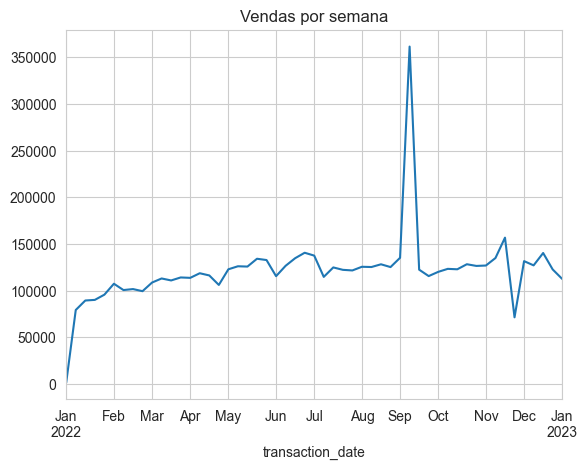

In [28]:
df_transacao['transaction_date'].dt.to_period('W').value_counts().sort_index().plot()
plt.title("Vendas por semana")
plt.show()

In [5]:
df_transacao

,internal_store_id,internal_product_id,distributor_id,transaction_date,reference_date,quantity,gross_value,net_value,gross_profit,discount,taxes,week
0,1073673009638227380,1564315626210978148,4,2022-01-01,2022-01-01,3.0,27.750000,27.750000,6.750000,9.15,0.000000,52
1,1493244414183181280,8728662573224341894,4,2022-01-01,2022-01-01,4.0,37.000000,37.000000,9.000000,12.20,0.000000,52
2,2904283814836480430,1507158896441533474,4,2022-01-01,2022-01-01,15.0,138.750000,138.750000,33.750000,45.75,0.000000,52
3,1073673009638227380,1078622472225871166,4,2022-01-01,2022-01-01,4.0,37.000000,37.000000,9.000000,12.20,0.000000,52
4,2904283814836480430,2983500104917811186,4,2022-01-01,2022-01-01,10.0,92.500000,92.500000,22.500000,30.50,0.000000,52
...,...,...,...,...,...,...,...,...,...,...,...,...
6425730,5642400835818820036,4623814317972718932,5,2022-12-31,2022-12-01,13.0,365.949997,363.610001,102.375000,0.00,2.340000,52
6425731,5321264642870219101,1763152755499955057,6,2022-12-31,2022-12-01,1.0,150.000000,148.759995,50.018993,0.00,1.240000,52
6425732,7261047694428751812,8966809205166240442,8,2022-12-31,2022-12-01,1.0,45.380001,45.200001,14.687001,0.00,0.180000,52
6425733,2822462494763887103,9070472035388935832,4,2022-12-31,2022-12-01,6.0,86.400002,73.588776,16.318775,9.60,12.811224,52


In [12]:
df_transacao_produto = df_transacao.merge(df_produto, left_on='internal_product_id', right_on='produto')

In [13]:
df_transacao_produto

,internal_store_id,internal_product_id,distributor_id,transaction_date,reference_date,quantity,gross_value,net_value,gross_profit,discount,taxes,week,produto,categoria,descricao,tipos,label,subcategoria,marca,fabricante
0,1073673009638227380,1564315626210978148,4,2022-01-01,2022-01-01,3.0,27.750000,27.750000,6.750000,9.15,0.000000,52,1564315626210978148,Non-Alcohol,SPARKLING ICE LEMONADE 12/17 NR,Non Alcohol,Core,Bourbon Whiskey,Sparkling Ice Classic Lemonade,Talking Rain
1,1493244414183181280,8728662573224341894,4,2022-01-01,2022-01-01,4.0,37.000000,37.000000,9.000000,12.20,0.000000,52,8728662573224341894,Non-Alcohol,SPARKLING ICE COCO PINEAPPLE 12/17,Non Alcohol,Core,Sour,Sparkling Ice Coconut Pineapple,Talking Rain
2,2904283814836480430,1507158896441533474,4,2022-01-01,2022-01-01,15.0,138.750000,138.750000,33.750000,45.75,0.000000,52,1507158896441533474,Non-Alcohol,SPARKLING ICE VARIETY 12/17 NR,Non Alcohol,Core,Other Wine,Sparkling Ice Variety Pack,Talking Rain
3,1073673009638227380,1078622472225871166,4,2022-01-01,2022-01-01,4.0,37.000000,37.000000,9.000000,12.20,0.000000,52,1078622472225871166,Non-Alcohol,SPARKLING ICE GRAPEFRUIT 12/17 NR,Non Alcohol,Core,Rum,Sparkling Ice Pink Grapefruit,Talking Rain
4,2904283814836480430,2983500104917811186,4,2022-01-01,2022-01-01,10.0,92.500000,92.500000,22.500000,30.50,0.000000,52,2983500104917811186,Non-Alcohol,SPARKLING ICE BLK/RAZ COLOR WRAPPED 12/17 NR,Non Alcohol,Core,Lager,Sparkling Ice Black Raspberry,Talking Rain
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6425730,5642400835818820036,4623814317972718932,5,2022-12-31,2022-12-01,13.0,365.949997,363.610001,102.375000,0.00,2.340000,52,4623814317972718932,Package,BUD LIGHT 4/6/12 LN,Package,Core,IPA,Bud Light,AB Anheuser Busch Inc
6425731,5321264642870219101,1763152755499955057,6,2022-12-31,2022-12-01,1.0,150.000000,148.759995,50.018993,0.00,1.240000,52,1763152755499955057,Draft,BRECKENRIDGE PALISADE PEACH 1/2 KEG,Draft,Discontinued,Red Wine,Breckenridge Peach Palisade Wheat,Tilray Brands
6425732,7261047694428751812,8966809205166240442,8,2022-12-31,2022-12-01,1.0,45.380001,45.200001,14.687001,0.00,0.180000,52,8966809205166240442,Package,ELYSIAN FULL CONTACT 4/6/12 CN,Package,Core,Wheat Beer,Elysian Full Contact,AB Anheuser Busch Inc
6425733,2822462494763887103,9070472035388935832,4,2022-12-31,2022-12-01,6.0,86.400002,73.588776,16.318775,9.60,12.811224,52,9070472035388935832,Distilled Spirits,ELEVEN JONES BLENDED WHISKEY 1.75L,Distilled Spirits,Core,Stout & Porter,Eleven Jones Whiskey,Sazerac ABA


In [14]:
df_pdv = pd.read_parquet('dataset/processed/pdv.parquet')

In [15]:
df_pdv

,pdv,premise,categoria_pdv,zipcode
0,2204965430669363375,On Premise,Mexican Rest,30741
1,5211957289528622910,On Premise,Hotel/Motel,80011
2,9024493554530757353,Off Premise,Convenience,80751
3,8659197371382902429,On Premise,Restaurant,80439
4,1400854873763881130,On Premise,Restaurant,30093
...,...,...,...,...
14414,5047149578012031122,Off Premise,Package/Liquor,81501
14415,8352177618955815208,Off Premise,Package/Liquor,80219
14416,7754182004766664314,On Premise,Special Event,81004
14417,9044929558186581877,On Premise,Other On Premise,81226


In [16]:
df_transacao_produto_pdv = df_transacao_produto.merge(df_pdv, left_on='internal_store_id', right_on='pdv')

In [17]:
df_transacao_produto_pdv

,internal_store_id,internal_product_id,distributor_id,transaction_date,reference_date,quantity,gross_value,net_value,gross_profit,discount,...,descricao,tipos,label,subcategoria,marca,fabricante,pdv,premise,categoria_pdv,zipcode
0,1073673009638227380,1564315626210978148,4,2022-01-01,2022-01-01,3.0,27.750000,27.750000,6.750000,9.15,...,SPARKLING ICE LEMONADE 12/17 NR,Non Alcohol,Core,Bourbon Whiskey,Sparkling Ice Classic Lemonade,Talking Rain,1073673009638227380,Off Premise,Grocery,30307
1,1493244414183181280,8728662573224341894,4,2022-01-01,2022-01-01,4.0,37.000000,37.000000,9.000000,12.20,...,SPARKLING ICE COCO PINEAPPLE 12/17,Non Alcohol,Core,Sour,Sparkling Ice Coconut Pineapple,Talking Rain,1493244414183181280,Off Premise,Super Center,30013
2,2904283814836480430,1507158896441533474,4,2022-01-01,2022-01-01,15.0,138.750000,138.750000,33.750000,45.75,...,SPARKLING ICE VARIETY 12/17 NR,Non Alcohol,Core,Other Wine,Sparkling Ice Variety Pack,Talking Rain,2904283814836480430,Off Premise,Grocery,30114
3,1073673009638227380,1078622472225871166,4,2022-01-01,2022-01-01,4.0,37.000000,37.000000,9.000000,12.20,...,SPARKLING ICE GRAPEFRUIT 12/17 NR,Non Alcohol,Core,Rum,Sparkling Ice Pink Grapefruit,Talking Rain,1073673009638227380,Off Premise,Grocery,30307
4,2904283814836480430,2983500104917811186,4,2022-01-01,2022-01-01,10.0,92.500000,92.500000,22.500000,30.50,...,SPARKLING ICE BLK/RAZ COLOR WRAPPED 12/17 NR,Non Alcohol,Core,Lager,Sparkling Ice Black Raspberry,Talking Rain,2904283814836480430,Off Premise,Grocery,30114
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6380635,5642400835818820036,4623814317972718932,5,2022-12-31,2022-12-01,13.0,365.949997,363.610001,102.375000,0.00,...,BUD LIGHT 4/6/12 LN,Package,Core,IPA,Bud Light,AB Anheuser Busch Inc,5642400835818820036,On Premise,Adult Entertainment,80204
6380636,5321264642870219101,1763152755499955057,6,2022-12-31,2022-12-01,1.0,150.000000,148.759995,50.018993,0.00,...,BRECKENRIDGE PALISADE PEACH 1/2 KEG,Draft,Discontinued,Red Wine,Breckenridge Peach Palisade Wheat,Tilray Brands,5321264642870219101,On Premise,Golf - Public,80723
6380637,7261047694428751812,8966809205166240442,8,2022-12-31,2022-12-01,1.0,45.380001,45.200001,14.687001,0.00,...,ELYSIAN FULL CONTACT 4/6/12 CN,Package,Core,Wheat Beer,Elysian Full Contact,AB Anheuser Busch Inc,7261047694428751812,Off Premise,Grocery,81007
6380638,2822462494763887103,9070472035388935832,4,2022-12-31,2022-12-01,6.0,86.400002,73.588776,16.318775,9.60,...,ELEVEN JONES BLENDED WHISKEY 1.75L,Distilled Spirits,Core,Stout & Porter,Eleven Jones Whiskey,Sazerac ABA,2822462494763887103,Off Premise,Package/Liquor,30004


In [ ]:
#df_transacao_produto_pdv.to_parquet('./dataset/processed/aggregated_dataset.parquet', engine='pyarrow', index=False)

In [20]:
df_transacao_produto_pdv.columns

Index(['internal_store_id', 'internal_product_id', 'distributor_id',
       'transaction_date', 'reference_date', 'quantity', 'gross_value',
       'net_value', 'gross_profit', 'discount', 'taxes', 'week', 'produto',
       'categoria', 'descricao', 'tipos', 'label', 'subcategoria', 'marca',
       'fabricante', 'pdv', 'premise', 'categoria_pdv', 'zipcode'],
      dtype='object')

In [19]:
df_transacao_produto_pdv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6380640 entries, 0 to 6380639
Data columns (total 24 columns):
 #   Column               Dtype         
---  ------               -----         
 0   internal_store_id    object        
 1   internal_product_id  object        
 2   distributor_id       object        
 3   transaction_date     datetime64[ns]
 4   reference_date       datetime64[ns]
 5   quantity             float64       
 6   gross_value          float64       
 7   net_value            float64       
 8   gross_profit         float64       
 9   discount             float64       
 10  taxes                float64       
 11  week                 UInt32        
 12  produto              object        
 13  categoria            object        
 14  descricao            object        
 15  tipos                object        
 16  label                object        
 17  subcategoria         object        
 18  marca                object        
 19  fabricante           

In [23]:
num_cols = ['quantity', 'gross_value', 'net_value', 'gross_profit', 'discount', 'taxes']
df_transacao_produto_pdv[num_cols].describe()

,quantity,gross_value,net_value,gross_profit,discount,taxes
count,6.380640e+06,6.380640e+06,6.380640e+06,6.380640e+06,6.380640e+06,6.380640e+06
mean,4.565927e+00,9.377601e+01,9.010691e+01,2.106671e+01,1.403426e+01,3.669108e+00
std,9.700701e+00,1.806347e+02,1.760184e+02,1.198285e+02,1.624189e+02,1.006339e+01
min,0.000000e+00,-3.984800e+04,-3.984800e+04,-2.743960e+05,-6.796000e+02,-4.106688e+00
25%,1.000000e+00,2.845000e+01,2.775000e+01,7.311999e+00,0.000000e+00,1.800000e-01
50%,2.000000e+00,4.256000e+01,4.100000e+01,1.056557e+01,2.380000e+00,5.400000e-01
75%,4.000000e+00,9.075000e+01,8.638000e+01,2.161525e+01,8.400000e+00,3.039677e+00
max,1.190000e+02,3.999996e+04,3.999815e+04,3.985366e+04,2.400830e+05,7.794127e+02


In [24]:
cat_cols = ['internal_store_id', 'internal_product_id', 'categoria', 'marca', 'subcategoria', 'categoria_pdv']

for col in cat_cols:
    print(f"\nColuna: {col}")
    print(df_transacao_produto_pdv[col].value_counts().head(10))  # top 10 categorias mais frequentes



Coluna: internal_store_id
internal_store_id
2430132255826117411    8455
7542707299572856789    8022
8078953974483084504    7745
1057223373529991552    7592
6825966060938407713    7511
1116765688108556050    7185
6001131494858904136    6981
8723723113467008071    6924
8146022441159978939    6812
2510617452472083145    6741
Name: count, dtype: int64

Coluna: internal_product_id
internal_product_id
4623814317972718932    107518
8174625658473329985    104000
3262679882836704514    102000
1029370090212151375     99751
8625590539951587748     92185
637448570435263100      85002
4098058333001424920     67271
1288112997726060694     64271
7029448080469668619     61974
7170592116007465797     61034
Name: count, dtype: int64

Coluna: categoria
categoria
Package              4539590
Non-Alcohol           947580
Distilled Spirits     537210
Draft                 188097
Wine                  116682
ABA Spirits            51056
Tobacco                  425
Name: count, dtype: int64

Coluna: marca
m

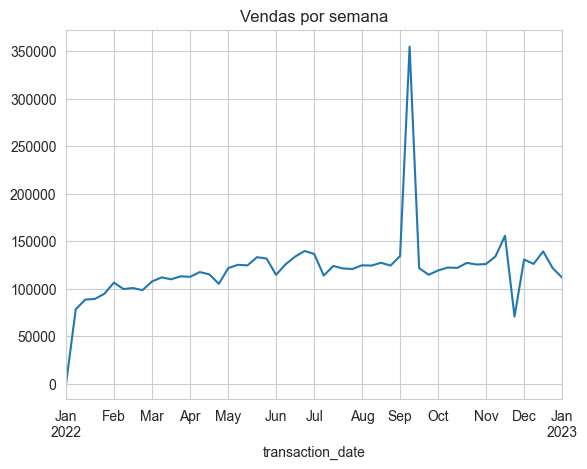

In [27]:
df_transacao_produto_pdv['transaction_date'].dt.to_period('W').value_counts().sort_index().plot()
plt.title("Vendas por semana")
plt.show()

C:\Users\br3nd\AppData\Local\Temp\ipykernel_29772\2076545485.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_values.values, y=top_values.index, palette="viridis")
C:\Users\br3nd\AppData\Local\Temp\ipykernel_29772\2076545485.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_values.values, y=top_values.index, palette="viridis")
C:\Users\br3nd\AppData\Local\Temp\ipykernel_29772\2076545485.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_values.values, y=top_values.index, palette="viridis")
C:\Users\br3nd\AppData\Lo

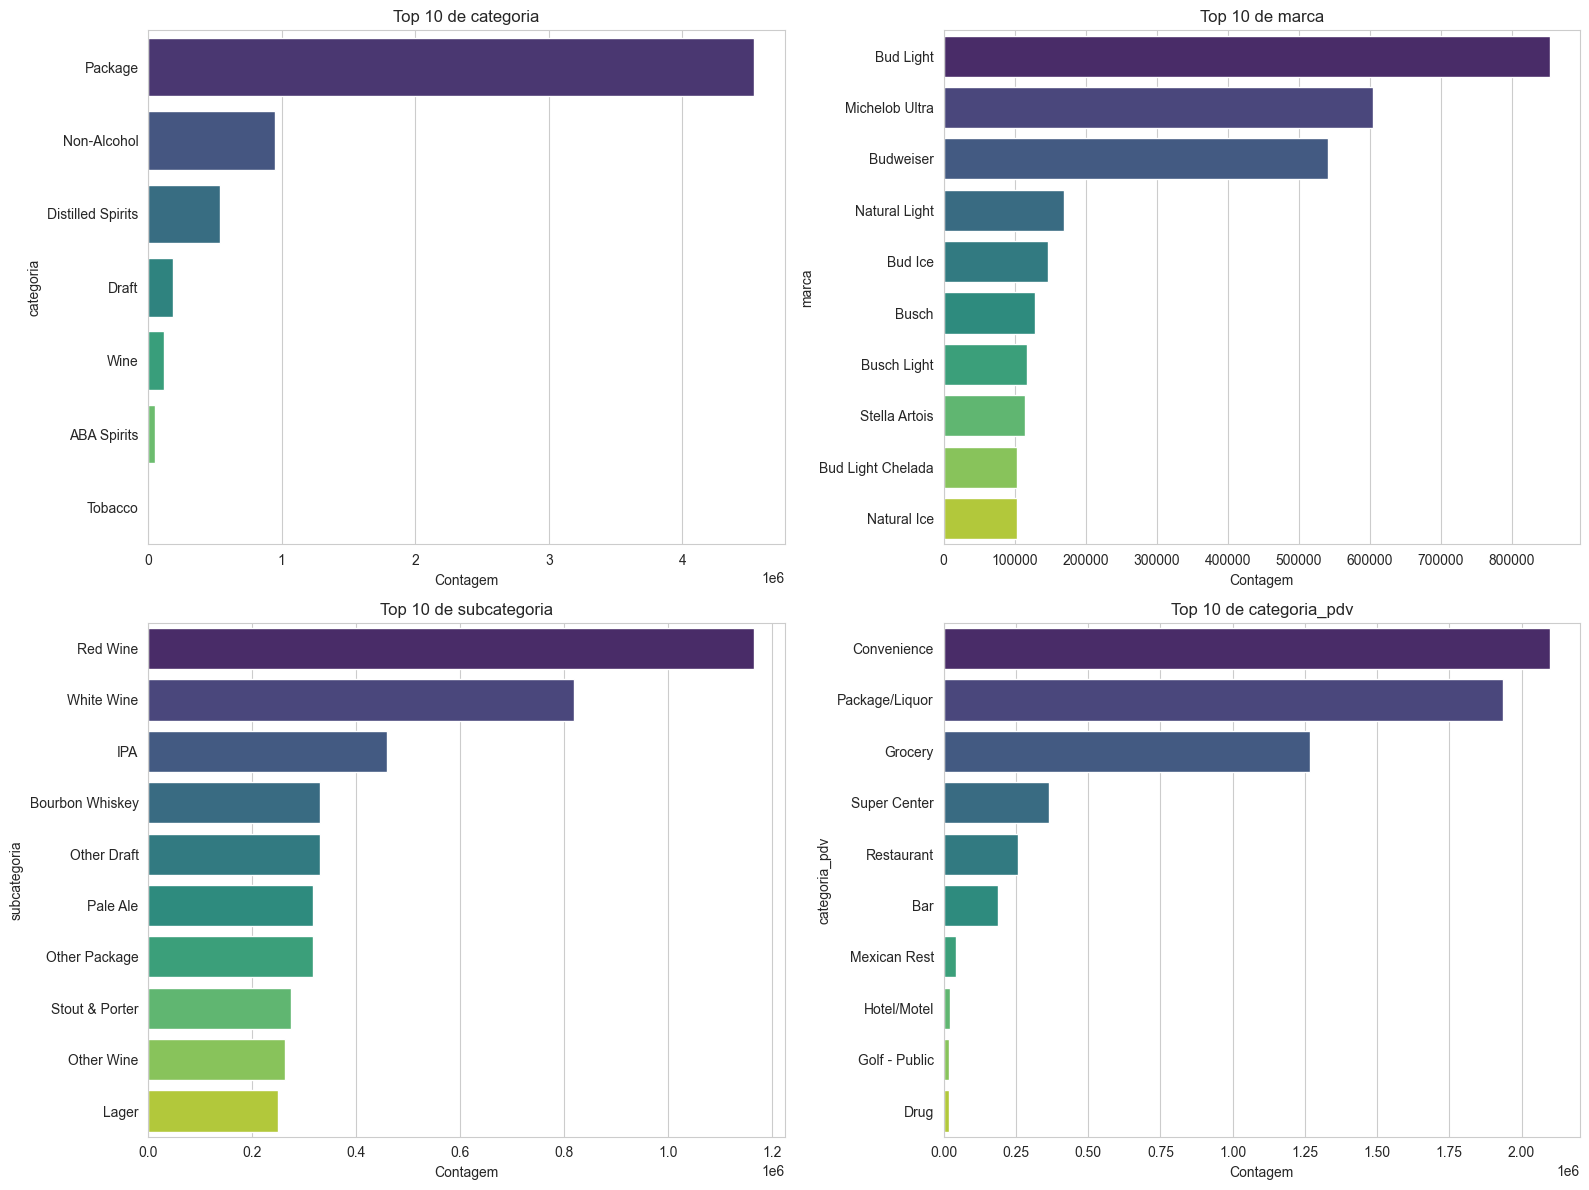

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Defina as colunas que quer plotar
cat_cols = ['categoria', 'marca', 'subcategoria', 'categoria_pdv']

# Ajustes gerais do gráfico
plt.figure(figsize=(16, 12))
sns.set_style("whitegrid")

for i, col in enumerate(cat_cols, 1):
    plt.subplot(2, 2, i)
    # Pegar top 10 valores mais frequentes
    top_values = df_transacao_produto_pdv[col].value_counts().nlargest(10)
    
    sns.barplot(x=top_values.values, y=top_values.index, palette="viridis")
    plt.title(f'Top 10 de {col}')
    plt.xlabel('Contagem')
    plt.ylabel(col)

plt.tight_layout()
plt.show()
